<a href="https://colab.research.google.com/github/OlenaM32/Data-Analysis/blob/main/OlenaMinenko_MaritimeExcercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Summart of the excercise


Let's explore the maritime world. In this dataset: https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst, you'll be able to visualize all the positions of ships off US coasts for one day: 01/08/2025. You can look this URL up directly in pandas, it can handle the decompression (this is a compressed CSV). This is a large dataset, so your operations may take longer than what we've seen so far. To understand what each column is, here is the data dictionary: https://coast.noaa.gov/data/marinecadastre/ais/data-dictionary.pdf

Please provide a notebook (.ipynb file) posted here and on your Github, in your data-analytics repo (please add a link to the repo in your submission) with the following:
Load the dataframe
Set the index to the base_date_time. Your index should be a DateTimeIndex
Clean the data: we don't want any row where the sog is null
First Analysis: When are boats out? Display a line graph where your x-axis is the hour of the day, and the y-axis is the number of unique vessels out at that hour. Hint: the MMSI column is a great way to identity a unique vessel. What time (UTC) saw the most boats out on the water? And the least? Does this track with what you could expect?
Second Analysis: let's look at a specific boat, the Henry Hudson (MMSI: 366651000). The owner of the boat has asked us how long the boat engines were active for that day. To get to this, you must:
 a) Figure out when the boat was "accelerating". Create a column called "acceleration", which is going to be the difference between each "sog". Hints: to achieve this, use the "diff()" function on your column. Be sure that your index is sorted, meaning the rows are sorted by time (.sort_index() is very helpful for this)
 b) Create a duration column, which is the difference between each "base_date_time"
 c) Once you have a column "acceleration" and "duration", we can assume that the boat engines were active if the "acceleration" is greater than 0. Filter your dataframe to only have rows where the acceleration is positive.
 d) Sum up the "duration" column to see how long the engines were active for that day. This will allow us to answer the boat captain
Bonus: create a function that takes the MMSI as a parameter, and return the active engine time for that day. Name this function calculate_total_active_engine_time.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"

In [ ]:
df = pd.read_csv('https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst')

set index to base_date_time

In [ ]:
df['base_date_time'] = pd.to_datetime(df['base_date_time'])
df.set_index('base_date_time', inplace=True)

In [ ]:
df = df.dropna(subset=['sog'])

first analysis

In [12]:
#resample nby hour and count unique MMSI
hourly_vessels = df['mmsi'].resample('H').nunique()

/tmp/ipykernel_1790/610565859.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_vessels = df['mmsi'].resample('H').nunique()


I accidentally had the df as counts instead of vessels

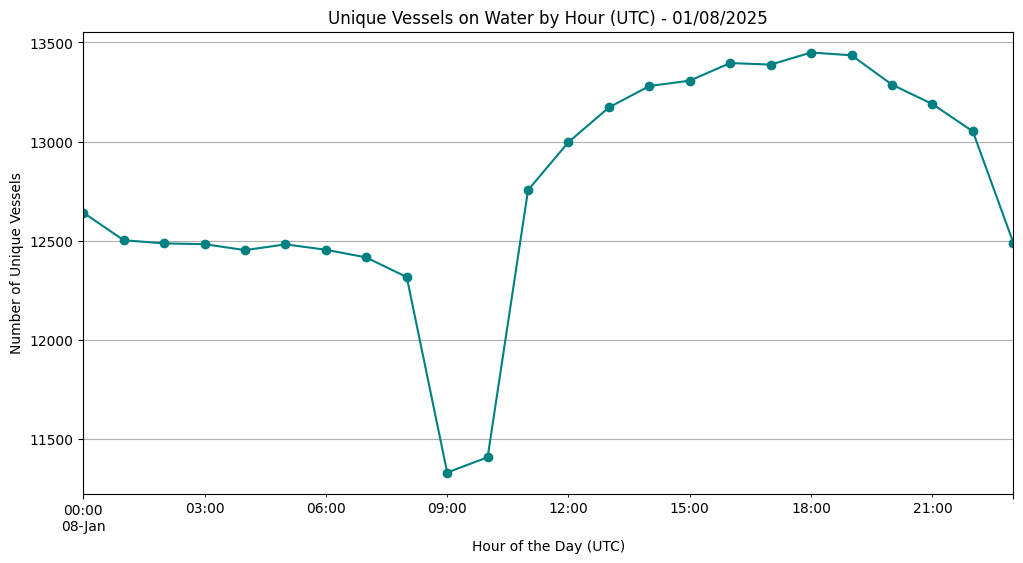

In [13]:
plt.figure(figsize=(12, 6))
hourly_vessels.plot(kind= 'line', marker= 'o', color= 'teal')
plt.title('Unique Vessels on Water by Hour (UTC) - 01/08/2025')
plt.xlabel('Hour of the Day (UTC)')
plt.ylabel('Number of Unique Vessels')
plt.grid(True)
plt.show()

In [14]:
#find max and min
peak_hour = hourly_vessels.idxmax()
low_hour = hourly_vessels.idxmin()
print(f"Most boats out: {peak_hour}: 00UTC")
print(f"least Hour: {low_hour}00 UTC")


Most boats out: 2025-01-08 18:00:00: 00UTC
least Hour: 2025-01-08 09:00:0000 UTC


Second analysis

In [15]:
#filter for henry hudson
mmsi_hudson = 366651000
hudson_df = df[df['mmsi'] == mmsi_hudson].copy()

In [16]:
hudson_df = hudson_df.sort_index()

In [17]:
hudson_df['acceleration'] = hudson_df['sog'].diff()
hudson_df['duration'] = hudson_df.index.to_series().diff()

In [18]:
print(hudson_df[['sog', 'acceleration', 'duration']].head(20))

                      sog  acceleration        duration
base_date_time                                         
2025-01-08 00:00:04   0.0           NaN             NaT
2025-01-08 00:01:14   5.5           5.5 0 days 00:01:10
2025-01-08 00:02:45  11.2           5.7 0 days 00:01:31
2025-01-08 00:03:55  11.6           0.4 0 days 00:01:10
2025-01-08 00:05:06  11.8           0.2 0 days 00:01:11
2025-01-08 00:06:45   6.5          -5.3 0 days 00:01:39
2025-01-08 00:07:55   0.0          -6.5 0 days 00:01:10
2025-01-08 00:09:06   0.1           0.1 0 days 00:01:11
2025-01-08 00:10:35   6.0           5.9 0 days 00:01:29
2025-01-08 00:12:03  13.7           7.7 0 days 00:01:28
2025-01-08 00:13:09  15.0           1.3 0 days 00:01:06
2025-01-08 00:14:33  15.4           0.4 0 days 00:01:24
2025-01-08 00:15:39   6.0          -9.4 0 days 00:01:06
2025-01-08 00:16:45   0.4          -5.6 0 days 00:01:06
2025-01-08 00:17:51   0.0          -0.4 0 days 00:01:06
2025-01-08 00:18:52   0.6           0.6 0 days 0

In [19]:
print(hudson_df['duration'].dtype)

timedelta64[ns]


In [20]:
active_engines = hudson_df[hudson_df['acceleration'] > 0]
total_active_time = active_engines['duration'].sum()
print(f"Total active time for Henry Hudson: {total_active_time}")


Total active time for Henry Hudson: 0 days 08:03:24
